<a href="https://colab.research.google.com/github/maazkhan872/AI-Powered-Financial-Auditor/blob/main/AI_Powered_Financial_Document_Auditor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and Exploring a Financial Dataset using Pandas



In [ ]:
import pandas as pd

# File path
file_path = "/content/Financial_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Show first 5 rows
print(df.head(10))


   Account_ID      Amount Currency   Period              Notes Is_Total  \
0           1  -339423.67      EUR  Q2-2023     Auto-generated      Yes   
1           2   339240.01      EUR  Q2-2023                NaN      Yes   
2           3   637221.28      USD  Q2-2023    Review required       No   
3           4   -76118.47      GBP  Q2-2023     Auto-generated       No   
4           5   466190.23      EUR  Q1-2023  Manual adjustment       No   
5           6   659225.93      EUR  Q4-2023     Auto-generated      Yes   
6           7  -234634.53      EUR  Q3-2023          Confirmed       No   
7           8  1780268.74      GBP  Q2-2023                NaN      Yes   
8           9   660953.49      GBP  Q2-2023  Manual adjustment      Yes   
9          10   798977.42      USD  Q4-2023    Review required       No   

         Parent_Account     Flag          Record_Type        Date  
0        All Activities    ERROR  Cash Flow Statement  20-02-2023  
1    Operating Expenses    ERROR     I

Duplicate Check on Financial Account Records

In [ ]:
# Total rows
total_rows = len(df)

# Unique Account_IDs
unique_ids = df['Account_ID'].nunique()

print("Total Rows:", total_rows)
print("Unique Account_IDs:", unique_ids)

if total_rows != unique_ids:
    print("WARNING: Duplicate Account_IDs found!")
    # Show duplicates
    duplicates = df[df.duplicated(subset=['Account_ID'], keep=False)]
    print(duplicates)
else:
    print("Account_IDs are unique.")


Total Rows: 3000
Unique Account_IDs: 3000
Account_IDs are unique.


Checking Missing Values in Key Financial Columns

In [ ]:
# Important columns
important_cols = ['Amount', 'Currency', 'Date', 'Record_Type', 'Flag']

# Count missing values
missing = df[important_cols].isnull().sum()
print("Missing Values:\n", missing)


Missing Values:
 Amount         0
Currency       0
Date           0
Record_Type    0
Flag           0
dtype: int64


Normalizing Record_Type Field for Consistency

In [ ]:
# Show unique Record_Type values
print("Before normalization:", df['Record_Type'].unique())

# Normalize to Title Case
df['Record_Type'] = df['Record_Type'].str.strip().str.title()

# Show again
print("After normalization:", df['Record_Type'].unique())


Before normalization: ['Cash Flow Statement' 'Income Statement' 'Balance Sheet']
After normalization: ['Cash Flow Statement' 'Income Statement' 'Balance Sheet']


Validating Record_Type Values Against Allowed Categories

In [ ]:
# Allowed categories
valid_record_types = ['Balance Sheet', 'Income Statement', 'Cash Flow Statement']

# Find invalid categories
invalid = df[~df['Record_Type'].isin(valid_record_types)]
print("Invalid Record_Types:\n", invalid)


Invalid Record_Types:
 Empty DataFrame
Columns: [Account_ID, Amount, Currency, Period, Notes, Is_Total, Parent_Account, Flag, Record_Type, Date]
Index: []


Boxplot Visualization of Financial Amounts

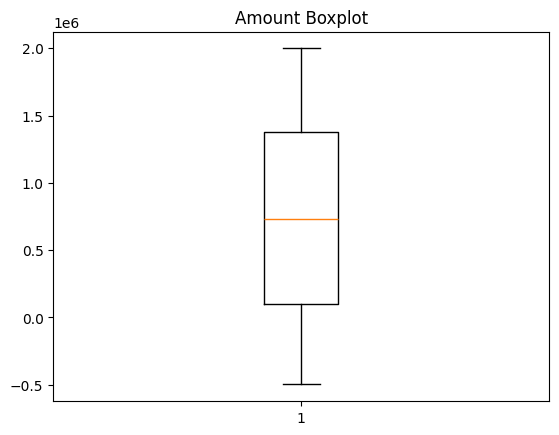

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Amount'])
plt.title("Amount Boxplot")
plt.show()


Calculating Thresholds for Outlier Detection

In [ ]:
upper_threshold = df['Amount'].quantile(0.95)
lower_threshold = df['Amount'].quantile(0.05)

print("Upper Threshold:", upper_threshold)
print("Lower Threshold:", lower_threshold)


Upper Threshold: 1889829.4019999998
Lower Threshold: -387261.491


Clipping Outliers in the Amount Column



In [ ]:
df['Amount'] = df['Amount'].clip(lower=lower_threshold, upper=upper_threshold)


Flagging Outliers in the Financial Amounts

In [ ]:
df['Outlier_Flag'] = df['Amount'].apply(lambda x: 'Outlier' if x > upper_threshold or x < lower_threshold else 'OK')


Analyzing Distribution of Flags in Financial Data



In [ ]:
label_counts = df['Flag'].value_counts()
print("Flag Label Counts:\n", label_counts)


Flag Label Counts:
 Flag
OK         2420
ERROR       327
FRAUD       128
UNUSUAL     125
Name: count, dtype: int64


Cleaning and Standardizing Date and Period Fields

In [ ]:
# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Show invalid dates
invalid_dates = df[df['Date'].isnull()]
print("Invalid Dates:\n", invalid_dates)

# Fill invalid dates
df['Date'] = df['Date'].fillna(pd.Timestamp('1900-01-01'))

# Show after filling
print("\nAfter filling invalid dates:\n", df)

# Convert Period to uppercase
df['Period'] = df['Period'].str.strip().str.upper()

# Show final DataFrame
print("\nFinal DataFrame:\n", df)


Invalid Dates:
       Account_ID       Amount Currency   Period              Notes Is_Total  \
4              5   466190.230      EUR  Q1-2023  Manual adjustment       No   
6              7  -234634.530      EUR  Q3-2023          Confirmed       No   
10            11  1889829.402      USD  Q3-2023  Manual adjustment       No   
12            13  1144071.270      EUR  Q3-2023          Confirmed       No   
13            14  1003905.980      USD  Q1-2023  Manual adjustment      Yes   
...          ...          ...      ...      ...                ...      ...   
2981        2982  1867020.570      USD  Q1-2023                NaN      Yes   
2982        2983  1151145.220      USD  Q2-2023  Manual adjustment      Yes   
2983        2984  1300430.310      GBP  Q1-2023          Confirmed      Yes   
2987        2988   707079.000      EUR  Q2-2023     Auto-generated      Yes   
2993        2994  1095568.270      USD  Q2-2023     Auto-generated       No   

             Parent_Account   Flag 

/tmp/ipython-input-11-2405550100.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


Validating Declared Totals Against Computed Sums

In [ ]:
# Group by Parent_Account and sum
grouped_totals = df.groupby('Parent_Account')['Amount'].sum().reset_index()

# Extract total rows
declared_totals = df[df['Is_Total'] == 'Yes'][['Parent_Account', 'Amount']].reset_index(drop=True)

# Merge both to compare
comparison = pd.merge(grouped_totals, declared_totals, on='Parent_Account', suffixes=('_Computed', '_Declared'))

# Check differences
comparison['Difference'] = comparison['Amount_Computed'] - comparison['Amount_Declared']

print(comparison)


      Parent_Account  Amount_Computed  Amount_Declared    Difference
0     All Activities     1.650580e+08       -339423.67  1.653975e+08
1     All Activities     1.650580e+08        660953.49  1.643971e+08
2     All Activities     1.650580e+08       1600722.12  1.634573e+08
3     All Activities     1.650580e+08       1870595.71  1.631875e+08
4     All Activities     1.650580e+08       1868358.91  1.631897e+08
...              ...              ...              ...           ...
1415         Revenue     1.485138e+08         92437.75  1.484213e+08
1416         Revenue     1.485138e+08       -143182.33  1.486570e+08
1417         Revenue     1.485138e+08       1328386.86  1.471854e+08
1418         Revenue     1.485138e+08       1202309.92  1.473115e+08
1419         Revenue     1.485138e+08       1470790.99  1.470430e+08

[1420 rows x 4 columns]


Financial Ratio Calculation Using Pivoted Account Data

In [ ]:
import pandas as pd

# Load data
df = pd.read_csv('/content/Financial_dataset.csv')

# Pivot table
pivot = df.pivot_table(index='Period', columns='Parent_Account', values='Amount', aggfunc='sum').reset_index()

# Columns check
print("Columns in Pivot:", list(pivot.columns))

# Compute Total Liabilities
pivot['Total Liabilities'] = pivot.get('Current Liabilities', 0).fillna(0) + pivot.get('Long-Term Liabilities', 0).fillna(0)

# Compute Ratios
pivot['Current_Ratio'] = pivot.get('Current Assets', 0) / pivot.get('Current Liabilities', 1)
pivot['Debt_Equity_Ratio'] = pivot['Total Liabilities'] / pivot.get('Equity', 1)

# Show final result
print(pivot[['Period', 'Current_Ratio', 'Debt_Equity_Ratio']])


Columns in Pivot: ['Period', 'All Activities', 'Bank', 'Cash', 'Current Assets', 'Current Liabilities', 'Equity', 'Expenses', 'Financing Activities', 'Fixed Assets', 'Investing Activities', 'Long-Term Liabilities', 'Marketing', 'Operating Activities', 'Operating Expenses', 'Revenue']
Parent_Account   Period  Current_Ratio  Debt_Equity_Ratio
0               Q1-2023       1.215771           1.983101
1               Q2-2023       0.679050           2.287398
2               Q3-2023       0.938252           2.179106
3               Q4-2023       0.700569           2.509257


Benford’s Law Analysis on Financial Amounts

In [ ]:
import numpy as np
from collections import Counter

# Seed for reproducibility
np.random.seed(42)

# Generate lognormal distributed amounts
amounts = np.random.lognormal(mean=10, sigma=1.0, size=3000)

# Extract leading digits
leading_digits = [int(str(int(x))[0]) for x in amounts if x > 0]

# Count occurrences
counts = Counter(leading_digits)

# Compute observed frequencies
total = sum(counts.values())
frequencies = {k: v / total for k, v in counts.items()}

# Expected Benford frequencies
benford_freq = {d: np.log10(1 + 1 / d) for d in range(1, 10)}

# Show comparison
print("Observed Frequencies:", frequencies)
print("Benford Expected:", benford_freq)


Observed Frequencies: {3: 0.129, 1: 0.31266666666666665, 4: 0.09666666666666666, 2: 0.18266666666666667, 7: 0.05466666666666667, 8: 0.04766666666666667, 5: 0.077, 9: 0.043, 6: 0.056666666666666664}
Benford Expected: {1: np.float64(0.3010299956639812), 2: np.float64(0.17609125905568124), 3: np.float64(0.12493873660829992), 4: np.float64(0.09691001300805642), 5: np.float64(0.07918124604762482), 6: np.float64(0.06694678963061322), 7: np.float64(0.05799194697768673), 8: np.float64(0.05115252244738129), 9: np.float64(0.04575749056067514)}


Configuring Visualization Environment for Financial Analysis



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For Jupyter or Colab
%matplotlib inline

# Optional styling
sns.set(style="whitegrid")


Visualizing Financial Trends, Distributions, and Correlations

/tmp/ipython-input-16-2515583734.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


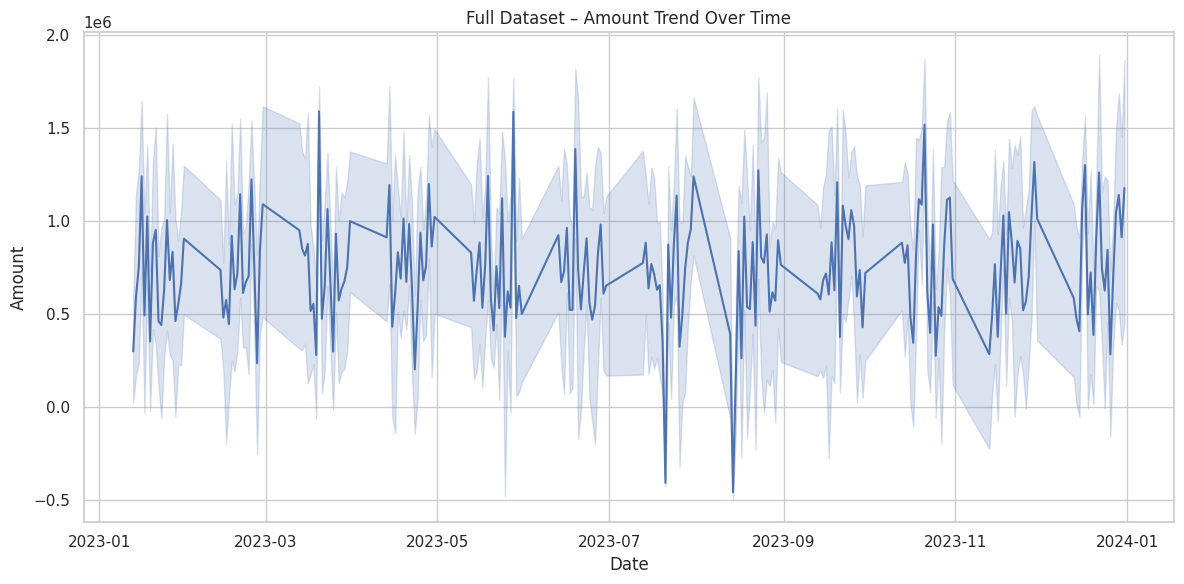

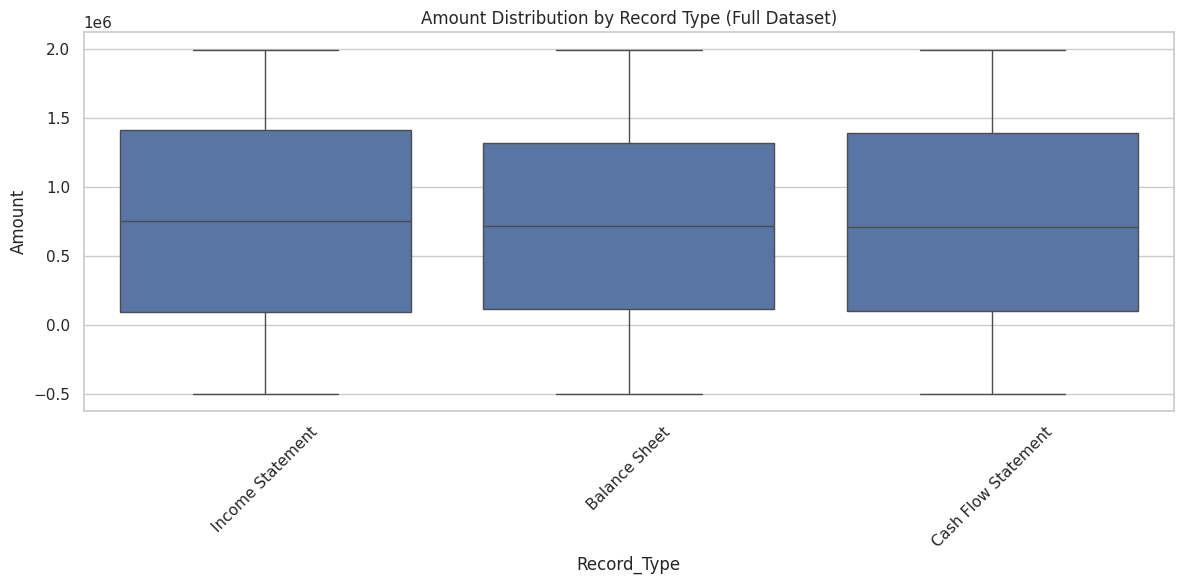

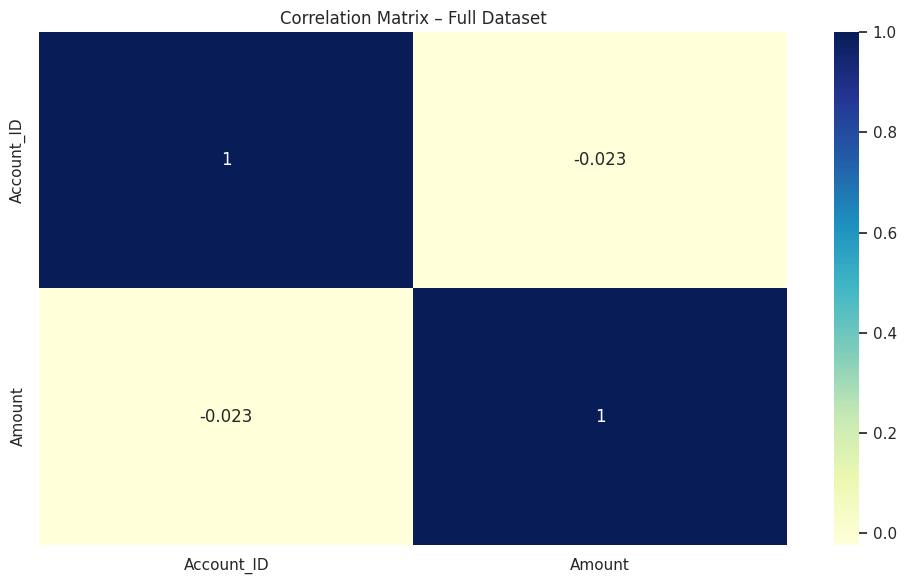

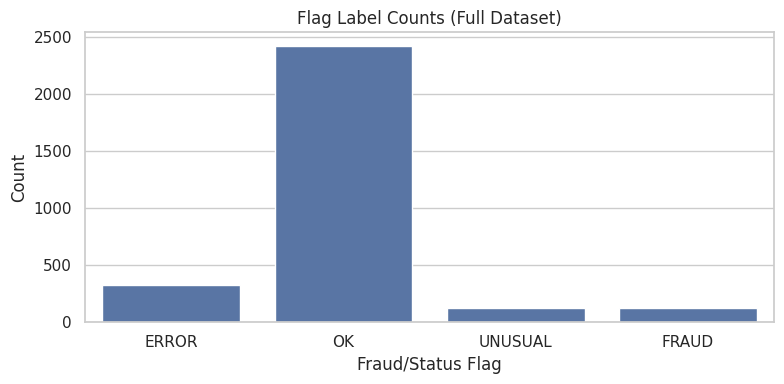

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Sort by date (important for time plots)
df = df.sort_values('Date')

# Plot entire dataset's amount over time
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Amount', data=df)
plt.title("Full Dataset – Amount Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='Record_Type', y='Amount', data=df)
plt.title("Amount Distribution by Record Type (Full Dataset)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix – Full Dataset")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='Flag', data=df)
plt.title("Flag Label Counts (Full Dataset)")
plt.xlabel("Fraud/Status Flag")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



Installing PaddleOCR and PaddlePaddle for Optical Character Recognition

In [ ]:
!pip install paddleocr
!pip install paddlepaddle -f https://www.paddlepaddle.org.cn/whl/linux/mkl/avx/stable.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

Text Extraction from Financial Documents using PaddleOCR

/tmp/ipython-input-18-3218796073.py:6: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=False, lang='en')
/usr/local/lib/python3.11/dist-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

inference.json: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/6.75M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

inference.yml: 0.00B [00:00, ?B/s]

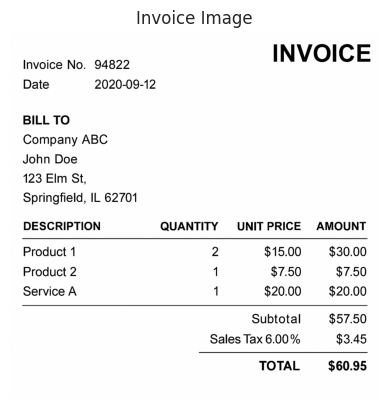

/tmp/ipython-input-18-3218796073.py:25: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(image_path)


Detected Text: n
Detected Text: a
Detected Text: o
Detected Text: t
Detected Text: o
Detected Text: e
Detected Text: e
Detected Text: e
Detected Text: e
Detected Text: e
Detected Text: e
Detected Text: i
Detected Text: e
Detected Text: e


In [ ]:
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import cv2

# Step 1: Initialize OCR
ocr = PaddleOCR(use_angle_cls=False, lang='en')

# Step 2: Set image path
image_path = '/content/ChatGPT Image Jul 7, 2025, 03_02_46 PM.png'

# Step 3: Load image
image = cv2.imread(image_path)

# Step 4: Check if image loaded
if image is None:
    print(" Image load failed! Check the path.")
else:
    # Optional: Show the image
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Invoice Image")
    plt.show()

    # Step 5: Perform OCR
    result = ocr.ocr(image_path)

    # Step 6: Display extracted text
    if result and len(result[0]) > 0:
        for line in result[0]:
            text = line[1][0]
            print("Detected Text:", text)
    else:
        print("No text detected.")


Automated Text Extraction from Images, PDFs, and Excel Files using PaddleOCR and PyMuPDF

In [ ]:
# Step 1: Install Required Libraries
!pip install paddleocr
!pip install "paddlepaddle==2.6.0" -f https://www.paddlepaddle.org.cn/whl/linux/mkl/avx/stable.html
!pip install pymupdf openpyxl

# Step 2: Import Libraries
import os
import fitz  # PyMuPDF for PDF parsing
import pandas as pd
from paddleocr import PaddleOCR
import mimetypes

# Step 3: Initialize OCR engine
ocr = PaddleOCR(use_angle_cls=True, lang='en')

# Step 4: Define Process Functions
def process_image(image_path):
    print(" Running OCR on Image...")
    result = ocr.ocr(image_path)
    full_text = ""
    for line in result[0]:
        full_text += line[1][0] + "\n"
    print("OCR Output:\n", full_text[:500])
    return full_text

def process_pdf(pdf_path):
    print("Reading PDF...")
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text()
    print("PDF Text Extracted:\n", text[:500])
    return text

def process_excel(excel_path):
    print("Reading Excel...")
    df = pd.read_excel(excel_path)
    print("Excel Preview:\n", df.head())
    print("Columns:", df.columns.tolist())
    print("Null Values:\n", df.isnull().sum())
    return df

# Step 5: Auto-Detect File Handler
def process_file(file_path):
    mime_type, _ = mimetypes.guess_type(file_path)
    ext = os.path.splitext(file_path)[-1].lower()

    print(f"\n Processing File: {file_path}")

    if mime_type and mime_type.startswith("image"):
        return process_image(file_path)
    elif ext == '.pdf':
        return process_pdf(file_path)
    elif ext in ['.xls', '.xlsx']:
        return process_excel(file_path)
    else:
        print(" Unsupported file format:", ext)
        return None

# Step 6: Add File Paths Here (Change these as needed)
files = [
    '/content/sample_invoice.pdf',
    '/content/sample_invoice.xlsx',
    '/content/ChatGPT Image Jul 7, 2025, 03_02_46 PM.png'
]

# Step 7: Run on All Files
for file in files:
    process_file(file)


Looking in links: https://www.paddlepaddle.org.cn/whl/linux/mkl/avx/stable.html


/tmp/ipython-input-32-960540757.py:14: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None)
The model(UVDoc) is not supported to run in MKLDNN mode! Using `paddle` instead!
Using official model (UVDoc), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

...

Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]


 Processing File: /content/sample_invoice.pdf
Reading PDF...
PDF Text Extracted:
 Sample Invoice
Invoice Number: INV-0001
Date: 2025-07-09
Customer: Ali Khan
Item
Quantity
Price
Total
Chocolate Box
2
Rs 500
Rs 1000
Dark Chocolate
3
Rs 300
Rs 900
Gift Wrap
1
Rs 100
Rs 100


 Processing File: /content/sample_invoice.xlsx
Reading Excel...
Excel Preview:
              Item  Quantity  Price  Total
0   Chocolate Box         2    500   1000
1  Dark Chocolate         3    300    900
2       Gift Wrap         1    100    100
Columns: ['Item', 'Quantity', 'Price', 'Total']
Null Values:
 Item        0
Quantity    0
Price       0
Total       0
dtype: int64

 Processing File: /content/ChatGPT Image Jul 7, 2025, 03_02_46 PM.png
 Running OCR on Image...


/tmp/ipython-input-32-960540757.py:19: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(image_path)


OCR Output:
 n
a
o
t
o
e
e
e
e
e
e
i
e
e



Automated AI Suggestions for Financial Total Discrepancies

In [ ]:
def suggest_correction(row):
    if pd.isnull(row['Difference']):
        return 'Missing entry — verify row'
    elif abs(row['Difference']) > 1000:
        return 'Significant mismatch — audit needed'
    elif abs(row['Difference']) > 0.01:
        return 'Recalculate total'
    else:
        return 'OK'

comparison['Suggestion'] = comparison.apply(suggest_correction, axis=1)
# Final print for suggestion summary
print("\n AI Suggestions Summary:")
print(comparison[['Parent_Account', 'Difference', 'Suggestion']])




 AI Suggestions Summary:
      Parent_Account    Difference                           Suggestion
0     All Activities  1.653975e+08  Significant mismatch — audit needed
1     All Activities  1.643971e+08  Significant mismatch — audit needed
2     All Activities  1.634573e+08  Significant mismatch — audit needed
3     All Activities  1.631875e+08  Significant mismatch — audit needed
4     All Activities  1.631897e+08  Significant mismatch — audit needed
...              ...           ...                                  ...
1415         Revenue  1.484213e+08  Significant mismatch — audit needed
1416         Revenue  1.486570e+08  Significant mismatch — audit needed
1417         Revenue  1.471854e+08  Significant mismatch — audit needed
1418         Revenue  1.473115e+08  Significant mismatch — audit needed
1419         Revenue  1.470430e+08  Significant mismatch — audit needed

[1420 rows x 3 columns]


Exporting AI Audit Report with Timestamp and Filtering for Issues

In [ ]:
from datetime import datetime

# STEP 7 – Enhanced Export Logic

# 1. Add audit timestamp
comparison['Checked_At'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# 2. Filter only rows that need review
issues_only = comparison[comparison['Suggestion'] != 'OK']

# 3. Generate filenames with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
excel_file = f"/content/audit_report_{timestamp}.xlsx"
csv_file = f"/content/audit_report_{timestamp}.csv"

# 4. Export to Excel and CSV
issues_only.to_excel(excel_file, index=False)
issues_only.to_csv(csv_file, index=False)

# 5. Console Output for Confirmation
print("Audit Report Generated:")
print(f" Excel File: {excel_file}")
print(f" CSV File:   {csv_file}")
print(f" Rows in Report: {len(issues_only)} (Only problematic entries)")


Audit Report Generated:
 Excel File: /content/audit_report_20250713_234911.xlsx
 CSV File:   /content/audit_report_20250713_234911.csv
 Rows in Report: 1420 (Only problematic entries)


Counting Occurrences of Each Flag Label



In [ ]:
print(df['Flag'].value_counts())


Flag
OK         2420
ERROR       327
FRAUD       128
UNUSUAL     125
Name: count, dtype: int64


Balancing Imbalanced Classes Using Upsampling

In [ ]:
# Import required function
from sklearn.utils import resample

# Separate each class
df_ok = df[df['Flag'] == 'OK']
df_error = df[df['Flag'] == 'ERROR']
df_fraud = df[df['Flag'] == 'FRAUD']
df_unusual = df[df['Flag'] == 'UNUSUAL']

# Resample each minority class to match OK
df_error_upsampled = resample(df_error, replace=True, n_samples=len(df_ok), random_state=42)
df_fraud_upsampled = resample(df_fraud, replace=True, n_samples=len(df_ok), random_state=42)
df_unusual_upsampled = resample(df_unusual, replace=True, n_samples=len(df_ok), random_state=42)

# Combine all
df_balanced = pd.concat([df_ok, df_error_upsampled, df_fraud_upsampled, df_unusual_upsampled])

# Check result
print(df_balanced['Flag'].value_counts())


Flag
OK         2420
ERROR      2420
FRAUD      2420
UNUSUAL    2420
Name: count, dtype: int64


SMOTE Oversampling Pipeline

Balanced class distribution after SMOTE:
ERROR: 2420
FRAUD: 2420
OK: 2420
UNUSUAL: 2420

Shape of the dataset:
X_train shape: (7744, 2)
X_test shape: (1936, 2)


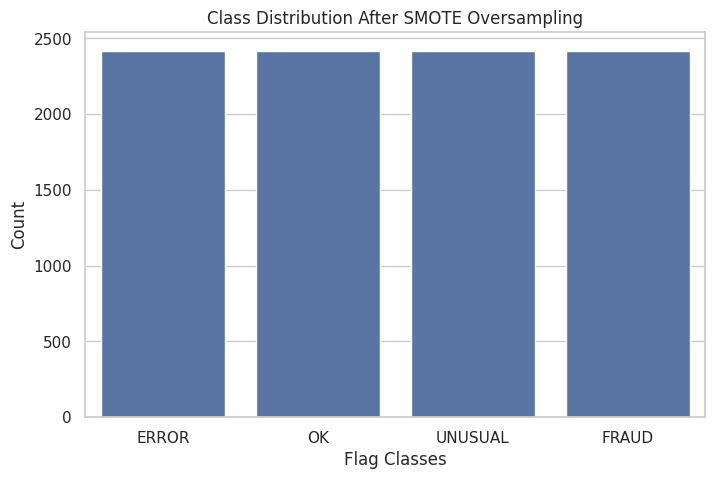

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Load your DataFrame (assuming 'df' is already defined and includes 'Flag')

# Encode target labels
le = LabelEncoder()
df['Flag_encoded'] = le.fit_transform(df['Flag'])

# Define features (X) and target (y)
X = df.select_dtypes(include='number').drop(columns=['Flag_encoded'])
y = df['Flag_encoded']

# Apply SMOTE for oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Show the class balance after SMOTE
unique, counts = np.unique(y_resampled, return_counts=True)
print("Balanced class distribution after SMOTE:")
for label, count in zip(le.inverse_transform(unique), counts):
    print(f"{label}: {count}")

# Check shape of train and test sets
print("\nShape of the dataset:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Visualize the class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=le.inverse_transform(y_resampled))
plt.title("Class Distribution After SMOTE Oversampling")
plt.xlabel("Flag Classes")
plt.ylabel("Count")
plt.show()


Collaboration Columns Added for Audit Review

In [ ]:
from datetime import datetime

# Add Collaboration Columns
comparison['Comments'] = ""
comparison['Reviewed_By'] = ""
comparison['Reviewed_At'] = ""

# Add Example Entries
comparison.loc[0, ['Comments', 'Reviewed_By', 'Reviewed_At']] = [
    "Amount mismatch confirmed. Recalculation required.",
    "Alice",
    datetime.now().strftime("%Y-%m-%d %H:%M:%S")
]

comparison.loc[1, ['Comments', 'Reviewed_By', 'Reviewed_At']] = [
    "Pending approval from finance team.",
    "Bob",
    datetime.now().strftime("%Y-%m-%d %H:%M:%S")
]

# Filter only commented rows
commented_rows = comparison[comparison['Comments'] != ""]
print(commented_rows.head())


   Parent_Account  Amount_Computed  Amount_Declared    Difference  \
0  All Activities     1.650580e+08       -339423.67  1.653975e+08   
1  All Activities     1.650580e+08        660953.49  1.643971e+08   

                            Suggestion           Checked_At  \
0  Significant mismatch — audit needed  2025-07-13 23:49:11   
1  Significant mismatch — audit needed  2025-07-13 23:49:11   

                                            Comments Reviewed_By  \
0  Amount mismatch confirmed. Recalculation requi...       Alice   
1                Pending approval from finance team.         Bob   

           Reviewed_At  
0  2025-07-13 23:52:54  
1  2025-07-13 23:52:54  


IFRS Compliance Check Performed on Audit Report

In [ ]:
import pandas as pd
from datetime import datetime

# Load the audit report from CSV
audit_df = pd.read_csv("/content/audit_report_20250709_212514.csv")

# Try to load the IFRS template from Excel
try:
    ifrs_template = pd.read_excel("/content/IFRS_Template.xlsx")

    # Check compliance by matching Parent_Account values
    audit_df['Compliant_IFRS'] = audit_df['Parent_Account'].isin(ifrs_template['Parent_Account'])

    # Export updated report with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    compliance_file = f"/content/compliance_checked_{timestamp}.xlsx"
    audit_df.to_excel(compliance_file, index=False)

    print(f" Compliance Report Exported Successfully:\n📄 {compliance_file}")

except FileNotFoundError:
    print(" IFRS_Template.xlsx not found. Please make sure the template is available.")


 Compliance Report Exported Successfully:
📄 /content/compliance_checked_20250714_000642.xlsx


Fraud Flag Classification Using Random Forest

Classification Report:

              precision    recall  f1-score   support

       ERROR       0.92      1.00      0.96       484
       FRAUD       0.95      1.00      0.97       484
          OK       1.00      0.84      0.91       484
     UNUSUAL       0.98      1.00      0.99       484

    accuracy                           0.96      1936
   macro avg       0.96      0.96      0.96      1936
weighted avg       0.96      0.96      0.96      1936



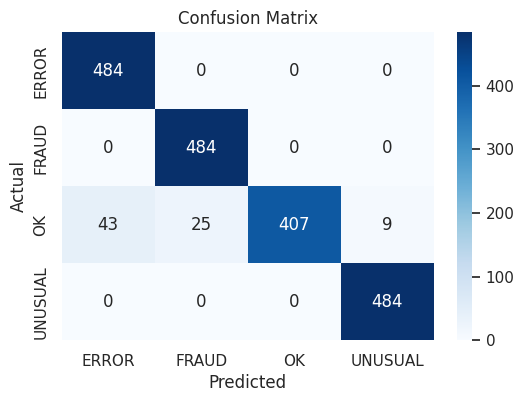

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Encode labels
le = LabelEncoder()
df_balanced['Flag_encoded'] = le.fit_transform(df_balanced['Flag'])

# Features and target
X = df_balanced.select_dtypes(include='number').drop(columns=['Flag_encoded'])
y = df_balanced['Flag_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate - Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Visualizing Feature Importance

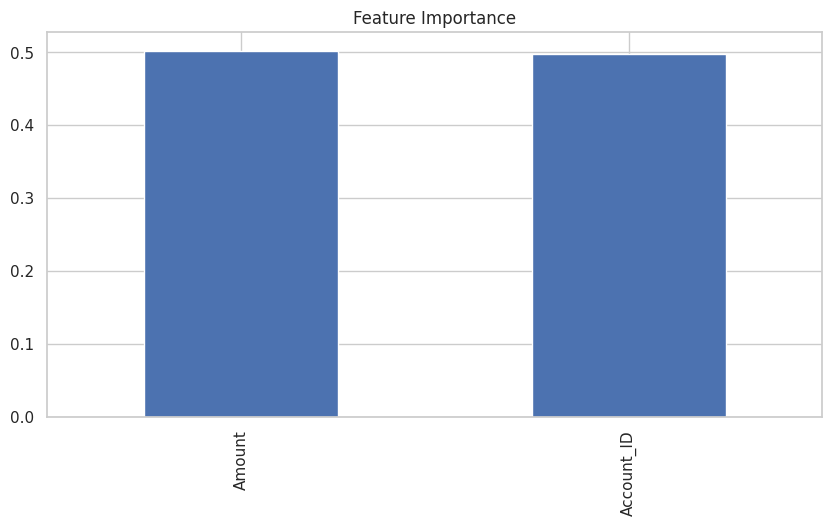

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot feature importances
feature_imp = pd.Series(model.feature_importances_, index=X.columns)
feature_imp.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title="Feature Importance")
plt.show()


Multiclass Financial Flag Detection using XGBoost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:07:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

       ERROR       0.86      0.96      0.90       484
       FRAUD       0.92      1.00      0.96       484
          OK       0.96      0.71      0.82       484
     UNUSUAL       0.95      1.00      0.98       484

    accuracy                           0.92      1936
   macro avg       0.92      0.92      0.91      1936
weighted avg       0.92      0.92      0.91      1936



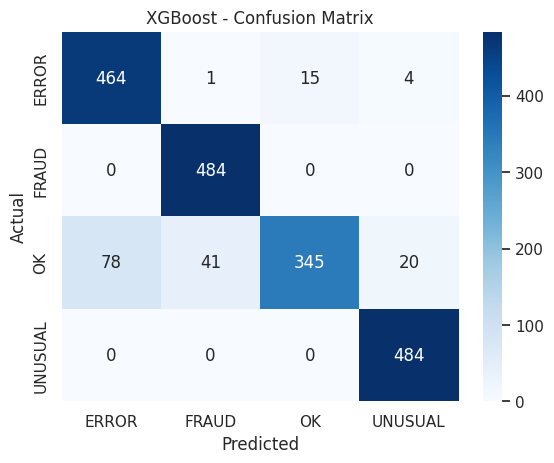

In [ ]:
!pip install xgboost
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Encode Labels (Flag column)
le = LabelEncoder()
df_balanced['Flag_encoded'] = le.fit_transform(df_balanced['Flag'])

# STEP 2: Select Features and Target
X = df_balanced.select_dtypes(include='number').drop(columns=['Flag_encoded'])
y = df_balanced['Flag_encoded']

# STEP 3: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# STEP 4: Train XGBoost Classifier
model = XGBClassifier(
    objective='multi:softmax',   # for multiclass classification
    num_class=4,                 # total number of classes in your target
    eval_metric='mlogloss',      # suitable for multi-class
    use_label_encoder=False,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 5: Predict
y_pred = model.predict(X_test)

# STEP 6: Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# STEP 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top Predictive Features in Financial Flag Detection

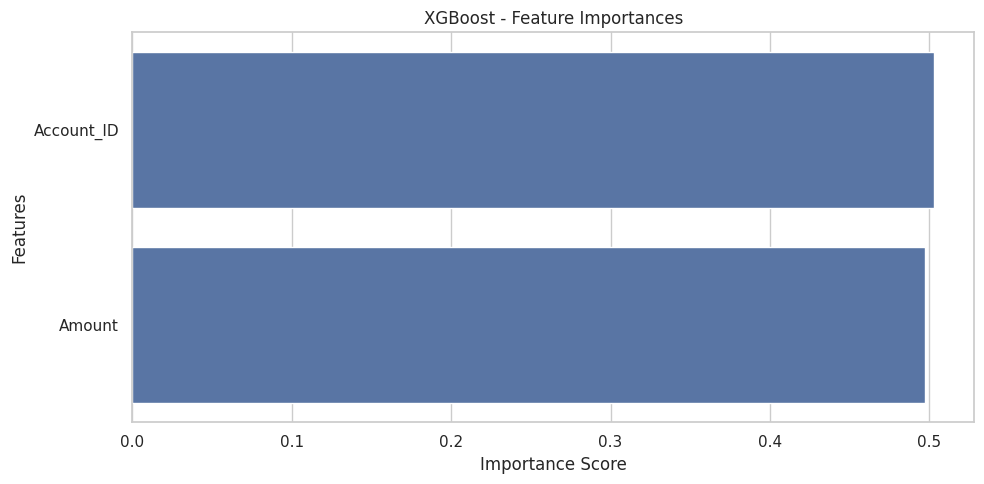

In [ ]:
# Plot feature importance
plt.figure(figsize=(10,5))
sns.barplot(
    x=model.feature_importances_,
    y=X.columns
)
plt.title("XGBoost - Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
